In [1]:
import torch
import torch.nn.functional as F
from torch.nn import ModuleList

from torch_geometric.nn import pool
import torch_geometric.transforms as T
from torch_geometric.nn import MLP, GENConv, to_hetero, MessageNorm, Linear

device = torch.device('cuda:1')
torch.set_default_dtype(torch.float32)
#device = torch.device('mps')

class GNN(torch.nn.Module):
    def __init__(self, in_channels,edge_in,layers,latent_dim, out_channels):
        super().__init__()
        self.proj = MLP(in_channels=in_channels,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='leaky_relu',norm='layer')
        self.edge_proj = MLP(in_channels=edge_in,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='leaky_relu',norm='layer')
        self.layers = layers

        self.encoding_layers = ModuleList([
            GENConv(latent_dim * 2, latent_dim, norm='layer',msg_norm=True,edge_dim=latent_dim)
            for _ in range(layers)])

        self.inv_proj = MLP(in_channels=latent_dim,hidden_channels=latent_dim,out_channels=out_channels,num_layers=2,act='leaky_relu',plain_last=True)
    
    def forward(self,x,edge_index,edge_attr,batch):
        x = self.proj(x)
        edge_attr = self.edge_proj(edge_attr)
        for conv in self.encoding_layers:
            x_global = pool.global_mean_pool(x,batch)
            x_expanded = x_global[batch]
            m = conv(torch.cat([x, x_expanded], dim=1), edge_index, edge_attr=edge_attr)
            x = x + m
        x = self.inv_proj(x)
        return x

In [2]:
## PyG Graph with Mesh Nodes
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import glob
import numpy as np
from scipy.spatial import KDTree
from scipy.stats import norm
import torch
from torch_geometric.data import Data
import pandas as pd

# Material encoding (1-h)
def stiffness_to_node_adj_edge_index(K: torch.Tensor, num_nodes: int, dof_per_node: int = 3) -> torch.Tensor: #mesh-mesh nodes
    K = K.coalesce()
    dof_rows, dof_cols = K.indices()
    node_rows = torch.div(dof_rows, dof_per_node, rounding_mode="floor")
    node_cols = torch.div(dof_cols, dof_per_node, rounding_mode="floor")
    ei = torch.stack([node_rows.long(), node_cols.long()], dim=0)
    mask = ei[0] != ei[1]
    ei = ei[:, mask]
    ei = torch.unique(ei, dim=1)
    return ei

def incidence_edges_from_conn(conn: np.ndarray, nodes: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    Nc, Nv = conn.shape
    c_idx = np.repeat(np.arange(Nc, dtype=np.int64), Nv)
    n_idx = conn.reshape(-1)
    edge_index = torch.from_numpy(np.vstack([c_idx, n_idx])).long()
    node_tensor = nodes.to(edge_index.device)
    conn_tensor = torch.from_numpy(conn).long().to(edge_index.device)
    #edge attribute -> mesh to element centroid in xyz
    elem_nodes = node_tensor[conn_tensor]
    centroids = elem_nodes.mean(dim=1, keepdim=True)
    rel_disp = (elem_nodes - centroids).reshape(-1, elem_nodes.size(-1))

    return edge_index, rel_disp

def mesh_edges_from_conn(conn: torch.Tensor) -> torch.Tensor:
    conn = conn.long()                             # [E, nverts]
    hex_edges = torch.tensor([
        [0,1], [1,2], [2,3], [3,0],     # bottom face
        [4,5], [5,6], [6,7], [7,4],     # top face
        [0,4], [1,5], [2,6], [3,7],     # vertical edges
    ])
    pairs = conn[:,hex_edges]          # [E, 12, 2]
    pairs = pairs.reshape(-1, 2)
    pairs = torch.unique(torch.sort(pairs, dim=1).values, dim=0).T
    edge_index = pairs
    return edge_index

def mesh_edges_nearest(nodes: torch.Tensor) -> torch.Tensor:
    # build mesh connections from nearest neighbors
    num_nodes = int(nodes.size(0))
    if num_nodes < 2:
        return torch.empty((2, 0), dtype=torch.long, device=nodes.device)

    coords = nodes.detach().cpu().numpy()
    k = min(8, num_nodes - 1)
    _, nn_idx = KDTree(coords).query(coords, k=k + 1, workers=-1)
    neighbors = nn_idx[:, 1:].reshape(-1)  # drop self
    src = np.repeat(np.arange(num_nodes, dtype=np.int64), k)

    pairs = torch.from_numpy(np.stack([src, neighbors], axis=1))
    pairs = torch.sort(pairs, dim=1).values
    pairs = torch.unique(pairs, dim=0)
    return pairs.t().to(nodes.device)

def nodes_topology_info(nodes: torch.Tensor) -> torch.Tensor:
    # build 3D descriptors of nearest neighbors, fitting into a distribution
    coords = nodes.detach().cpu().numpy()  # [N, 3]
    num_nodes = coords.shape[0]

    k = min(125, num_nodes - 1)  # cap k to available neighbors
    _, nn_idx = KDTree(coords).query(coords, k=k + 1, workers=-1)  # include self
    neighbor_idx = nn_idx[:, 1:]  # drop self index, shape (N, k)

    neighbor_coords = coords[neighbor_idx]             # (N, k, 3)
    rel = neighbor_coords - coords[:, None, :]         # relative vectors
    mu = torch.from_numpy(rel.mean(axis=1))                              # (N, 3)
    sigma = torch.from_numpy(rel.std(axis=1, ddof=0))                    # (N, 3)
    return torch.cat([mu, sigma], dim=1)


# Connectivity
# mesh nodes <-> mesh nodes
# mesh nodes <-> element nodes

def data_to_graph(path:str,device):
    data = Data()
    simdata = torch.load(path,weights_only=False)
    conn = simdata["elements"]
    conn = conn.cpu().numpy() if isinstance(conn, torch.Tensor) else np.asarray(conn)
    nodes = simdata['nodes']
    top_desc = nodes_topology_info(nodes)
    #c2n_ei, c2n_w = incidence_edges_from_conn(conn,nodes)  # [2, E_cn], [E_cn, 1]
    
    # mesh node properties: positions, forces, BC, dirichlet displacement
    data.pos = nodes #                                             [N,3]
    data.bc = simdata['boundary']
    data.f_ext = simdata['ext_forces'] #forces in timeseries format     [T,N,3]
    data.tpl = top_desc #nearest-neighbor topology descriptors    [N,6]

    # element node properties: material, stiffness matrix
    #data['elements'].stiffness = #stiffness is a learned feature

    # target properties
    # mesh: displacement over time
    data.f_ts = simdata['forces'] #forces in timeseries format     [T,N,3]
    data.u_ts = simdata['u_history']

    # mesh-mesh: distance
    #ei = stiffness_to_node_adj_edge_index(simdata["stiffness"], num_nodes=nodes.size(0), dof_per_node=nodes.size(1))
    ei = mesh_edges_from_conn(simdata["elements"]) # [2,N]
    #ei = mesh_edges_nearest(nodes)
    src, dst = ei
    #edge_mat = one_hot(vocab, device=device).unsqueeze(0).repeat(int(ei.shape[1]), 1)
    disp = (nodes[dst] - nodes[src]).float()
    data.edge_index = ei
    data.edge_attr = disp
    data = data.to(device)
    return data

#data_to_graph('../base/torchfem_dataset/processed/simulation_dump_3.pt','../base/torchfem_dataset/processed/mat.csv',device)

def generate_dataset(data_dir:str):
    device = torch.device('cpu')
    file = data_dir
    samples = []
    #for file in files:
        #if filename > 50:
        #    continue
    data = data_to_graph(file,device)
    samples.append(data)
    print(file)

    print(len(samples))
    return samples

#dataset = generate_dataset('../datasets/simple_beam/sim_2.pt')
dataset = generate_dataset('../torchfem_dataset/simple_beam_reduced/sim_2.pt')
#torch.save(dataset, "../datasets/simple_beam/test_dataset.pt")

../torchfem_dataset/simple_beam_reduced/sim_2.pt
1


In [3]:
from torch_geometric.utils import is_undirected, to_undirected

#ei = dataset['edge_index'].T
ea = dataset[0].edge_attr
edge_index = dataset[0].edge_index
edge_index,ea = to_undirected(edge_index,edge_attr=ea)
print('Undirected?' if is_undirected(edge_index) else 'Directed!')
dataset[0].edge_attr = ea
dataset[0].edge_index = edge_index

Undirected?


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import coalesce
from torch_geometric.data import HeteroData


def build_laststep_features(data, dtype=torch.float32):
    ## Collapse to peak load timestep
    #print(data.keys)
    len = data.f_ext.shape[0]
    t = int(len-1)
    # Nodes: x = [pos, bc, f_ext[-1], f_int[-1]]  (no leakage of u_ts into x)
    #pos   = data['nodes'].pos.to(dtype) #no need to include
    bc    = data.bc.to(dtype)
    f_ext = torch.Tensor(data.f_ext[t]).to(dtype)
    data.fext = torch.Tensor(data.f_ext[t]).to(dtype)
    data.x = torch.cat([bc, f_ext], dim=-1)


    # Target: nodes â†’ u_ts[-1] (3D)
    data.y_u = data.u_ts[t].to(dtype)
    data.y_fint = data.f_ts[t].to(dtype)

    # (Optional) free large tensors you won't use further to save RAM/VRAM
    del data.bc, data.u_ts, data.f_ext, data.f_int, data.material#, data['nodes'].pos
    del data.f_ts

    #print(data.keys)
    return data

def build_timestep_features(data,dtype=torch.float32):
    ## Split data into multiple timesteps
    len = data.f_ext.shape[0]
    data_ts = []
    for t in range(1,len-1):
        # Nodes: x = [pos, bc, f_ext[-1], f_int[-1]]  (no leakage of u_ts into x)
        d = data.clone()
        bc    = d.bc.to(dtype)
        f_ext = torch.Tensor(d.f_ext[t]).to(dtype)
        d.fext = torch.Tensor(d.f_ext[t]).to(dtype)
        d.x = torch.cat([bc, f_ext], dim=-1).to(dtype)

        # Target: nodes â†’ u_ts[-1] (3D)
        d.y_u = d.u_ts[t].to(dtype)
        d.y_fint = d.f_ts[t].to(dtype)
        del d.bc, d.u_ts, d.f_ext, d.f_int, #, d.pos
        del d['elements'].s_ts, d['elements'].d_ts, d['elements'].material, d['nodes'].f_ts, d['elements'].s_ts, d['elements']
        del d[('nodes','belongs_to','elements')], d[('elements','contributes','nodes')]
        data_ts.append(d)

    del data['nodes'].bc, data['nodes'].u_ts, data['nodes'].f_ext, data['nodes'].f_int, data['elements'].material, data['nodes'].pos
    del data['elements'].s_ts, data['elements'].d_ts, data['elements'].material, data['nodes'].f_ts, data['elements'].s_ts, data['elements']
    del data[('nodes','belongs_to','elements')], data[('elements','contributes','nodes')]

    return data_ts

class StandardScaler:
    def __init__(self):
        self.node_stats = {}
        self.edge_stats = {}

    def fit(self, dataset):
        node_x = torch.cat([d.x[:,3:].float() for d in dataset],dim=0)
        node_f = torch.cat([d.y_fint.float() for d in dataset],dim=0)
        node_u = torch.cat([d.y_u.float() for d in dataset],dim=0)

        # compute mean/std
        
        self.node_stats['nodes_x'] = {
            "mean": torch.zeros_like(node_x.mean(dim=0, keepdim=True)),
            "std":  node_x.std(dim=0, keepdim=True) + 1e-8}
        self.node_stats['nodes_f'] = {
            "mean": torch.zeros_like(node_f.mean(dim=0, keepdim=True)),
            "std":  node_f.std(dim=0, keepdim=True) + 1e-8}
        self.node_stats['nodes_u'] = {
            "mean": torch.zeros_like(node_u.mean(dim=0, keepdim=True)),
            "std":  node_u.std(dim=0, keepdim=True) + 1e-8}

    def transform(self, data: torch.Tensor):
        # apply normalization
        x = data.x[:,3:].float()
        m_x = self.node_stats['nodes_x']["mean"]
        s_x = self.node_stats['nodes_x']["std"]
        data.x[:,3:] = (x - m_x) / s_x

        y_f = data.y_fint.float()
        m_f = self.node_stats['nodes_f']["mean"]
        s_f = self.node_stats['nodes_f']["std"]
        data.y_fint = (y_f - m_f) / s_f
        
        y_u = data.y_u.float()
        m_u = self.node_stats['nodes_u']["mean"]
        s_u = self.node_stats['nodes_u']["std"]
        data.y_u = (y_u - m_u) / s_u

        return data
    
    def inverse_transform(self, data: torch.Tensor):
        # Nodes
        m, s = self.node_stats["nodes_u"]["mean"], self.node_stats["nodes_u"]["std"]
        data = data * s + m

        return data
    
    def inverse_transform_multihead(self, data: torch.Tensor):
        # Nodes
        m, s = self.node_stats["nodes_u"]["mean"], self.node_stats["nodes_u"]["std"]
        data[:,:3] = data[:,:3] * s + m
        
        mf, sf = self.node_stats["nodes_f"]["mean"], self.node_stats["nodes_f"]["std"]
        data[:,3:] = data[:,3:] * sf + mf

        return data

scaler = StandardScaler()

In [10]:
import torch
import torch.nn.functional as F
from torch import nn
import pandas as pd

from torch_geometric.nn import pool
import torch_geometric.transforms as T
from torch_geometric.nn import MLP, GENConv, to_hetero
from torch_geometric.loader import DataLoader

import os

#device = torch.device('cpu')
print(device)
alias = '1222'
os.makedirs(f"../genconv/{alias}",exist_ok=True)

scaler = StandardScaler()

dataset_type = 's' # 's', 't', 'c'

# Unprocessed dataset - collapsed to single timestep
if dataset_type == 's':
    dataset_p = [build_laststep_features(d).to(device) for d in dataset]
    scaler.fit(dataset_p)
    train_set = [scaler.transform(d) for d in dataset_p]

# Unprocessed dataset - each timestep as a new sample
if dataset_type == 't':
    dataset_p = [build_timestep_features(d) for d in dataset]
    dataset_f = [row[-1] for row in dataset_p]
    dataset_p = [item for row in dataset_p for item in row]
    scaler.fit(dataset_f)
    train_set = [scaler.transform(d) for d in dataset_p]

del dataset, dataset_p
torch.cuda.empty_cache()
print(alias)

def compute_losses(batch, pred):
    # Nodes
    y_u    = batch.y_u
    #y_fint = batch['nodes'].y_fint
    #fext   = batch['nodes'].x[:,3:6]
    #bc = batch['nodes'].x[:,:3]
    #pu  = pred['u'] 
    #print(pred)
    
    #pf = pred['fint']

    L_u    = F.mse_loss(pred, y_u,reduction='mean')
    #L_fint = F.mse_loss(pf, y_fint)
    #L_eq   = F.mse_loss(((torch.ones_like(bc)-bc)*(pf - fext)).sum(),torch.zeros((),device=bc.device))

    loss = L_u
    return loss, {'L_u': L_u.item()}#, 'L_fint': L_fint.item(), 'L_eq': L_eq.item(),


cuda:1
1222


In [7]:
## Training Loop
model = GNN(in_channels=6,edge_in=3,layers=12,latent_dim=128,out_channels=3).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=5e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=300)

def run_epoch(loader, train=True):
    model.train(train)
    total, last_loss_dict = 0.0, {}
    for batch in loader:
        batch = batch.to(device)
        opt.zero_grad(set_to_none=True)
        #print(batch)

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch)
        
        loss, loss_dict = compute_losses(batch, pred)
        last_loss_dict = loss_dict  # keep something to return

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        total += loss.item()

    steps = max(1, len(loader))
    return total / steps, last_loss_dict


EPOCHS = 2000
best_val = float("inf")
best_state = None
loss_records = []

torch.cuda.empty_cache()
train_loader = DataLoader(train_set, batch_size=1, shuffle=True)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_ld = run_epoch(train_loader, train=True)

    scheduler.step(train_loss)
    loss_records.append({"epoch": epoch, "train_loss": train_loss})

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | train {train_loss:.6f}")
    if epoch == 1 or epoch % 20 == 0:
        torch.save(model.state_dict(), f"../genconv/{alias}/weights_{epoch}.pt")

print("Best val:", best_val)

pd.DataFrame(loss_records).to_csv(f"../genconv/{alias}/losses.csv", index=False)

Epoch 001 | train 1.669889
Epoch 005 | train 1.036218
Epoch 010 | train 0.847695
Epoch 015 | train 0.836651
Epoch 020 | train 0.779353
Epoch 025 | train 0.748983
Epoch 030 | train 0.741416
Epoch 035 | train 0.731017
Epoch 040 | train 0.718705
Epoch 045 | train 0.741080
Epoch 050 | train 0.737233
Epoch 055 | train 0.737330
Epoch 060 | train 0.779368
Epoch 065 | train 0.749412
Epoch 070 | train 0.720995
Epoch 075 | train 0.729523
Epoch 080 | train 0.720634
Epoch 085 | train 0.711061
Epoch 090 | train 0.719349
Epoch 095 | train 0.720361
Epoch 100 | train 0.700933
Epoch 105 | train 0.704048
Epoch 110 | train 0.696672
Epoch 115 | train 0.690184
Epoch 120 | train 0.734645
Epoch 125 | train 0.733966
Epoch 130 | train 0.723836
Epoch 135 | train 0.717480
Epoch 140 | train 0.728714
Epoch 145 | train 0.711690
Epoch 150 | train 0.711572
Epoch 155 | train 0.708765
Epoch 160 | train 0.703577
Epoch 165 | train 0.699251
Epoch 170 | train 0.694860
Epoch 175 | train 0.694212
Epoch 180 | train 0.706601
E

In [22]:
from copy import deepcopy
from pathlib import Path

model = GNN(in_channels=6,edge_in=3,layers=12,latent_dim=128,out_channels=3).to(device)
alias = '1222'
ckpt_path = Path(f"../genconv/{alias}/weights_2000.pt")
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state)
model.eval()

#train_set, val_set = split_dataset(dataset_val, val_ratio=0.1)
train_loader = DataLoader(train_set, batch_size=1, shuffle=True)
#original_loader = DataLoader(dataset, batch_size=1, shuffle=False)

out_samples = []
with torch.no_grad():
    for data in train_loader:
        d = deepcopy(data)
        d = d.to(device)
        x = d.x
        edge_index = d.edge_index
        edge_attr = d.edge_attr
        #edge_index = data.edge_index_dict.values()
        #edge_attr = data.edge_attr_dict.values()
        batch = d.batch

        #print(x.dtype,edge_index.dtype,edge_attr.dtype,batch.dtype)
        pred = model(x,edge_index,edge_attr,batch)

        # Detach and move predictions to CPU for saving
        d.pred_u = pred

        d.y_u_unnorm = d.y_u
        d.pred_u_unnorm = d.pred_u

        d.y_u = scaler.inverse_transform(d.y_u)
        d.pred_u = scaler.inverse_transform(d.pred_u)
        # Move the data structure back to CPU before attaching CPU tensors
        d = d.to('cpu')

        # Attach predictions into the dictionary

        out_samples.append(d)

# Save to a new file
#save_path = "../base/test_dataset/preds_1208_conn.pt"
save_path = f"../genconv/{alias}/preds_{alias}.pt"
torch.save(out_samples, save_path)
print(f"Saved {len(out_samples)} samples with predictions to {save_path}")

Saved 1 samples with predictions to ../genconv/1222/preds_1222.pt


(np.float64(-104.98091803210043),
 np.float64(380.8626911496951),
 np.float64(-50.25064158655671),
 np.float64(641.5824745036073))

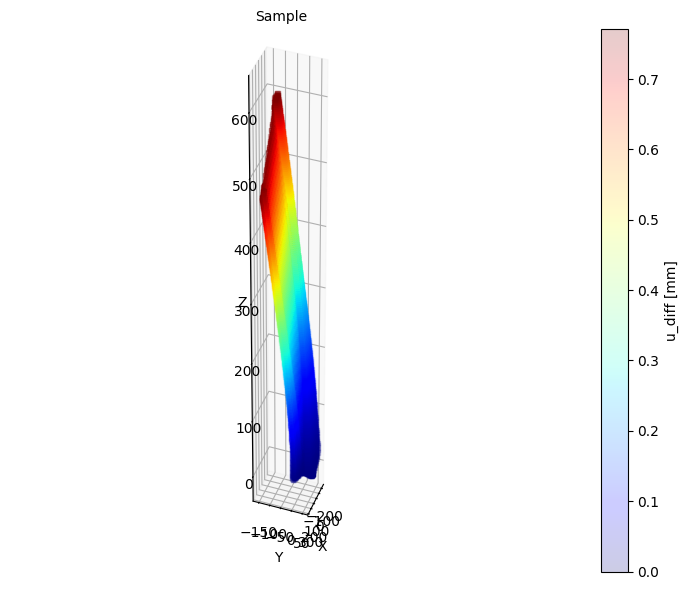

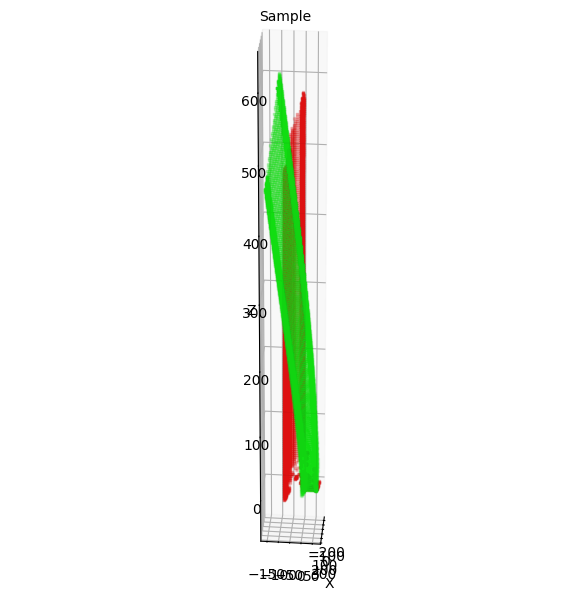

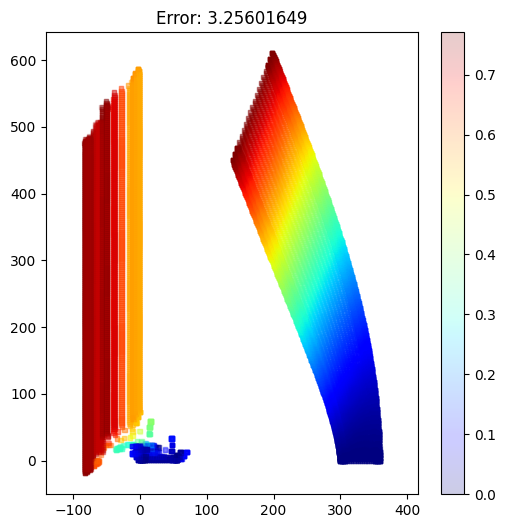

In [23]:
## Visualization - Matplotlib 3D Scatter Plot
import matplotlib.pyplot as plt
import numpy as np
import torch
#alias = '1222'
out_samples = torch.load(f"../genconv/{alias}/preds_{alias}.pt",weights_only=False)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
plt.title(f'Sample',fontsize=10)

sample = 0

vis_scale = 50
u = out_samples[sample]['y_u_unnorm']
pos_init = out_samples[sample]['pos']
pos_true = pos_init+out_samples[sample]['y_u_unnorm']*vis_scale
pos_pred = pos_init+out_samples[sample]['pred_u_unnorm']*vis_scale
#pos_diff = np.linalg.norm(pos_true-pos_pred,axis=-1)/vis_scale
pos_diff = np.linalg.norm(out_samples[sample]['y_u'],axis=-1)
pos_diff_pred = np.linalg.norm(out_samples[sample]['pred_u'],axis=-1)
mask = pos_diff > 1e-6
if mask.any():
    pos_delta = np.mean(np.abs(pos_diff_pred[mask] - pos_diff[mask]) / pos_diff[mask])
else:
    pos_delta = 0.0

#force_true = out_samples[sample]['nodes']['y_fint']
#force_pred = out_samples[sample]['nodes']['pred_fint']
#force_diff = np.linalg.norm(force_true-force_pred,axis=-1)

#sc = ax.scatter(pos_init[:,0],pos_init[:,1],pos_init[:,2],s=2,marker='s',c='#1111dd',alpha=0.2,depthshade=True)
#sc2 = ax.scatter(pos_true[:,0],pos_true[:,1],pos_true[:,2],s=2,marker='s',c='#11dd11',alpha=0.1,depthshade=True)
#sc3 = ax.scatter(pos_pred[:,0],pos_pred[:,1],pos_pred[:,2],s=2,marker='s',c='#dd1111',alpha=0.2,depthshade=True)
sc = ax.scatter(pos_true[:,0],pos_true[:,1],pos_true[:,2],s=10,marker='s',c=pos_diff,cmap='jet',alpha=0.2,depthshade=True)
plt.colorbar(sc, ax=ax, label='u_diff [mm]')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=40, azim=20)
ranges = np.ptp(out_samples[sample]['pos'].T, axis=1)
ax.set_box_aspect(ranges)

plt.tight_layout()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
plt.title(f'Sample',fontsize=10)

#sc = ax.scatter(pos_init[:,0],pos_init[:,1],pos_init[:,2],s=10,marker='s',c='#1111dd',alpha=0.2,depthshade=True)
#plt.colorbar(sc, ax=ax, label='force_diff [N]')
sc2 = ax.scatter(pos_true[:,0],pos_true[:,1],pos_true[:,2],s=2,marker='s',c='#11dd11',alpha=0.1,depthshade=True)
sc3 = ax.scatter(pos_pred[:,0],pos_pred[:,1],pos_pred[:,2],s=2,marker='s',c='#dd1111',alpha=0.1,depthshade=True)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=30, azim=5)
ranges = np.ptp(out_samples[sample]['pos'].T, axis=1)
ax.set_box_aspect(ranges)

plt.tight_layout()


plt.figure(figsize=(6,6))
sc = plt.scatter(pos_pred[:,1],pos_pred[:,2],s=10,marker='s',c=pos_diff_pred,cmap='jet',alpha=0.2)
sc = plt.scatter(pos_true[:,1]+300,pos_true[:,2],s=10,marker='s',c=pos_diff,cmap='jet',alpha=0.2)
plt.colorbar()
plt.title(f'Error: {pos_delta:.8f}')
plt.axis('equal')